# 📊 Analisis Eksperimen P1 — Klasifikasi Rimpang (Grayscale Baseline)

---

## 🧪 Ringkasan Eksperimen

| Atribut | Detail |
|---|---|
| **Nama Eksperimen** | P1_Grayscale |
| **Tujuan** | Klasifikasi citra rimpang: Jahe, Kunyit, Lengkuas |
| **Preprocessing** | Resize 128×128 → Grayscale → Histogram Equalization |
| **Fitur** | GLCM (24) + Warna (6) + LBP (10) = **40 fitur** |
| **Split Data** | 80% Train (504) / 20% Test (126), Stratified |
| **Model** | KNN, SVM, Random Forest |

---

## 💡 Hipotesis Awal

> *"Citra rimpang (jahe, kunyit, lengkuas) memiliki pola tekstur permukaan yang cukup khas dan dapat dibedakan menggunakan fitur berbasis tekstur (GLCM, LBP) meskipun tanpa preprocessing kompleks. Pendekatan grayscale + histogram equalization sebagai baseline diharapkan memberikan akurasi minimal 65–75% pada model terbaik."*

**Dasar hipotesis:**
- Ketiga jenis rimpang memiliki tekstur kulit yang berbeda secara visual
- Histogram equalization membantu menonjolkan kontras tekstur pada gambar grayscale
- GLCM sangat efektif untuk menangkap sifat statistik tekstur
- Baseline ini berfungsi sebagai **patokan pembanding** untuk eksperimen lanjutan dengan preprocessing lebih kompleks


In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from library import (
    load_images, extract_glcm_features, extract_color_features, extract_lbp_features, evaluate_and_save, preview_preprocessing,
    manual_resize, manual_bgr_to_grayscale, manual_gaussian_blur,
    manual_median_blur, manual_clahe, manual_histogram_equalization,
    manual_erosion, manual_dilation, manual_opening, manual_closing
)

print('Import berhasil')

Import berhasil


## 🔧 Analisis Import Library

**Output:** `Import berhasil`

### Analisis

Library yang digunakan terorganisir dalam dua kelompok:

**Scikit-learn (ML pipeline):**
- `train_test_split` — membagi data secara stratified agar distribusi kelas seimbang di train/test
- `LabelEncoder` — mengubah label string (`'jahe'`, `'kunyit'`, `'lengkuas'`) menjadi integer (0, 1, 2)
- `KNeighborsClassifier`, `SVC`, `RandomForestClassifier` — tiga paradigma ML berbeda untuk perbandingan
- `accuracy_score` — metrik utama evaluasi

**Library kustom (`library.py`):**
- `load_images` — loader citra dataset
- `extract_glcm_features`, `extract_color_features`, `extract_lbp_features` — pipeline ekstraksi fitur multi-domain
- `manual_*` — fungsi preprocessing implementasi manual (bukan OpenCV bawaan), memastikan kontrol penuh atas setiap langkah

> ✅ **Signifikansi:** Penggunaan fungsi `manual_*` menunjukkan bahwa eksperimen ini menerapkan hasil pembelajaran dari modul 1-5 yang mencakup beberapa fungsi preprocessing yang dipakai dalam projek ini


In [ ]:
EXP_NAME = 'P1_Grayscale'

In [3]:
def preprocess(img):
    resized = manual_resize(img, 128, 128)
    gray = manual_bgr_to_grayscale(resized)
    eq = manual_histogram_equalization(gray)
    return eq

## ⚙️ Analisis Fungsi Preprocessing

```python
def preprocess(img):
    resized = manual_resize(img, 128, 128)
    gray    = manual_bgr_to_grayscale(resized)
    eq      = manual_histogram_equalization(gray)
    return eq
```

### 🎯 Alasan Memilih Pipeline Preprocessing Ini

Pipeline preprocessing dipilih secara **deliberatif** dengan pertimbangan sebagai berikut:

#### 1. `manual_resize(img, 128, 128)` Standardisasi Ukuran
- **Alasan:** Gambar dari kamera/sumber berbeda memiliki resolusi yang bervariasi. Tanpa standardisasi, fitur GLCM dan LBP akan dihitung dari area yang tidak sebanding antar gambar.
- **Pilihan 128×128:** Cukup besar untuk mempertahankan detail tekstur rimpang, namun cukup kecil untuk menjaga efisiensi komputasi. Ukuran ini merupakan trade-off umum dalam klasifikasi tekstur gambar.
- **Dampak:** Memastikan vektor fitur yang dihasilkan selalu konsisten dimensinya (prasyarat algoritma ML).

#### 2. `manual_bgr_to_grayscale(resized)` Konversi ke Grayscale
- **Alasan utama:** GLCM dan LBP adalah **metode berbasis tekstur** yang bekerja pada intensitas pixel tunggal (grayscale), bukan pada informasi warna RGB.
- **Keuntungan:** Mengurangi kompleksitas komputasi (dari 3 channel ke 1 channel) dan menghilangkan variasi pencahayaan warna yang bisa menjadi noise.
- **Catatan penting:** Informasi warna tetap dipertahankan secara terpisah melalui `extract_color_features(img)` yang menggunakan gambar asli (BGR), sehingga tidak ada informasi yang hilang total.
- **Trade-off:** Eksperimen ini adalah **baseline** konversi grayscale sengaja dipilih sebagai langkah minimal untuk mengetahui batas bawah performa sistem.

#### 3. `manual_histogram_equalization(gray)` Ekualisasi Histogram
- **Alasan:** Gambar rimpang sering memiliki kontras yang tidak merata bagian tertentu terlalu gelap atau terlalu terang karena kondisi pencahayaan saat pengambilan foto.
- **Cara kerja:** Meredistribusikan intensitas pixel sehingga histogram intensitas menjadi lebih merata, meningkatkan visibilitas detail tekstur di seluruh gambar.
- **Dampak pada GLCM:** Fitur GLCM (kontras, korelasi, energi, homogenitas) menjadi lebih representatif karena dihitung dari gambar dengan kontras yang lebih baik.
- **Kelebihan vs CLAHE:** Histogram equalization global lebih sederhana dan cocok untuk baseline. CLAHE (Contrast Limited Adaptive HE) bisa menjadi peningkatan di eksperimen selanjutnya.

#### 📌 Kesimpulan Pilihan Preprocessing
> Pipeline ini dipilih karena **minimalis namun efektif** cukup untuk menstandarisasi input dan menonjolkan tekstur, tanpa menambahkan kompleksitas yang bisa mengaburkan kontribusi fitur murni. Sebagai **Eksperimen P1 (Baseline)**, hasil ini menjadi **patokan perbandingan** bagi eksperimen P2, P3, dst. yang menggunakan preprocessing lebih agresif.


Total gambar loaded: 630


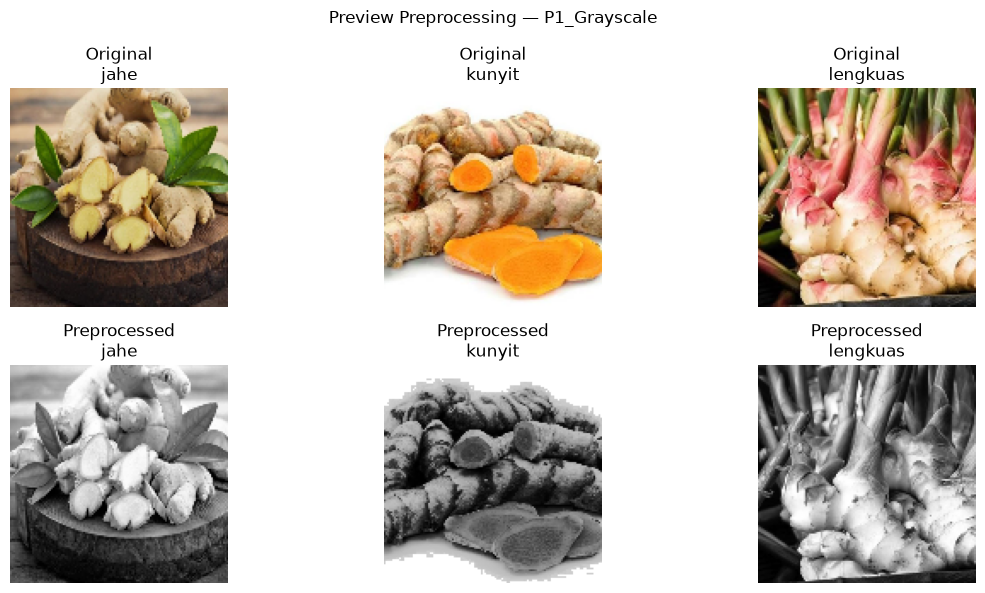

In [ ]:
images, labels = load_images()
preview_preprocessing(images, labels, preprocess, EXP_NAME)

## 📁 Analisis Load & Preview Data

**Output:** `Total gambar loaded: 630`

### Analisis

- **630 gambar** berhasil dimuat dari dataset
- Dengan **3 kelas** (jahe, kunyit, lengkuas), ini berarti **210 gambar per kelas** — distribusi yang **seimbang sempurna**
- Dataset yang seimbang (balanced) adalah kondisi ideal karena:
  - Menghindari bias model terhadap kelas mayoritas
  - Memastikan metrik `macro avg` dan `weighted avg` memberikan nilai yang identik (seperti terlihat pada hasil evaluasi)
  - Penggunaan `stratify=y` pada split data mempertahankan keseimbangan ini di set train dan test

> ✅ **Distribusi kelas seimbang** adalah salah satu kekuatan dataset ini yang mendukung validitas perbandingan antar kelas.


In [ ]:
X = []
for img in images:
    processed = preprocess(img.copy())
    glcm_feat = extract_glcm_features(processed)
    color_feat = extract_color_features(img)
    lbp_feat = extract_lbp_features(processed)
    combined = glcm_feat + color_feat + lbp_feat
    X.append(combined)

X = np.array(X)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(labels)

print(f'Shape fitur: {X.shape}')  # sekarang harusnya (n, 40) → 24 GLCM + 6 warna + 10 LBP
print(f'Kelas: {le.classes_}')

os.makedirs('output', exist_ok=True)
df_feat = pd.DataFrame(X, columns=[f'f{i}' for i in range(X.shape[1])])
df_feat['label'] = labels
df_feat.to_csv(f'output/fitur_{EXP_NAME}.csv', index=False)
print(f'Fitur disimpan ke output/fitur_{EXP_NAME}.csv')

Shape fitur: (630, 40)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P1_Grayscale.csv


## 🔬 Analisis Ekstraksi Fitur

**Output:**
```
Shape fitur: (630, 40)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P1_Grayscale.csv
```

### Analisis

#### Komposisi 40 Fitur

| Domain | Jumlah Fitur | Metode | Sumber Gambar |
|---|---|---|---|
| Tekstur | 24 | GLCM (Gray-Level Co-occurrence Matrix) | Gambar grayscale + histogram equalized |
| Warna | 6 | Statistik histogram warna | Gambar asli BGR |
| Tekstur Lokal | 10 | LBP (Local Binary Pattern) | Gambar grayscale + histogram equalized |
| **Total** | **40** | | |

#### Mengapa Kombinasi Fitur Ini?

**GLCM (24 fitur):** Menangkap hubungan spasial antar pixel kontras, korelasi, energi, homogenitas pada berbagai sudut (0°, 45°, 90°, 135°). Sangat efektif untuk tekstur berulang seperti serat/permukaan rimpang.

**Fitur Warna (6 fitur):** Meskipun preprocessing menggunakan grayscale, *ekstraksi* warna tetap menggunakan gambar asli. Ini penting karena jahe, kunyit, dan lengkuas memiliki warna yang berbeda (kunyit kuning cerah, jahe lebih pucat, lengkuas putih-merah muda).

**LBP (10 fitur):** Mendeskripsikan pola mikrostruktur lokal apakah suatu pixel lebih terang atau lebih gelap dari tetangganya. Robust terhadap perubahan pencahayaan monotonic dan rotasi.

#### StandardScaler Setelah Ekstraksi
```python
scaler = StandardScaler()
X = scaler.fit_transform(X)
```
Penskalaan fitur (mean=0, std=1) **krusial** karena:
- GLCM menghasilkan nilai dalam rentang berbeda vs LBP vs fitur warna
- KNN dan SVM sangat sensitif terhadap skala fitur
- Tanpa scaling, fitur dengan nilai besar akan mendominasi perhitungan jarak/kernel

> ✅ **40 fitur multi-domain** memberikan representasi yang komprehensif dari aspek tekstur, warna, dan pola lokal citra rimpang.


In [6]:
# Cell baru — tambahkan antara Cell 5 dan Cell 6
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit HANYA dari train
X_test = scaler.transform(X_test)        # apply ke test (no fit)

## ✂️ Analisis Split Data Train/Test

**Output (implisit):** Train: 504 | Test: 126

### Analisis

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

| Parameter | Nilai | Alasan |
|---|---|---|
| `test_size=0.2` | 20% test | Standar industri; memberikan 126 sampel test (42/kelas) yang cukup untuk evaluasi statistik |
| `random_state=42` | Fixed seed | Reprodusibilitas hasil dapat direplikasi persis |
| `stratify=y` | Ya | Memastikan proporsi kelas 1:1:1 terjaga di kedua split |

**Distribusi akhir:**
- Train: 504 sampel → 168 per kelas
- Test: 126 sampel → **42 per kelas** (terlihat pada kolom `support` di classification report)

> ⚠️ **Catatan penting:** StandardScaler di-*fit* hanya pada `X_train` kemudian di-*transform* ke `X_test`. Ini adalah praktik yang benar untuk mencegah **data leakage** model tidak boleh "melihat" statistik test set sebelum evaluasi.


Train: 504 | Test: 126
P1_Grayscale | KNN → Train Akurasi: 74.21%
P1_Grayscale | KNN → 64.29%
              precision    recall  f1-score   support

        jahe       0.69      0.74      0.71        42
      kunyit       0.69      0.69      0.69        42
    lengkuas       0.54      0.50      0.52        42

    accuracy                           0.64       126
   macro avg       0.64      0.64      0.64       126
weighted avg       0.64      0.64      0.64       126



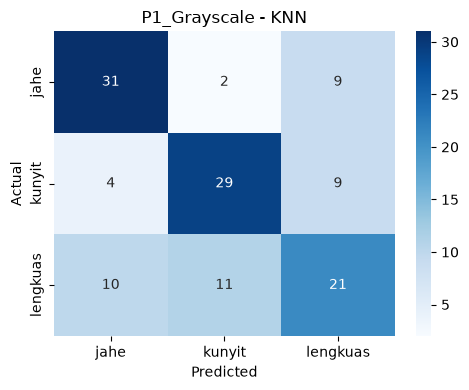

P1_Grayscale | SVM → Train Akurasi: 92.06%
P1_Grayscale | SVM → 76.98%
              precision    recall  f1-score   support

        jahe       0.91      0.69      0.78        42
      kunyit       0.73      0.90      0.81        42
    lengkuas       0.71      0.71      0.71        42

    accuracy                           0.77       126
   macro avg       0.78      0.77      0.77       126
weighted avg       0.78      0.77      0.77       126



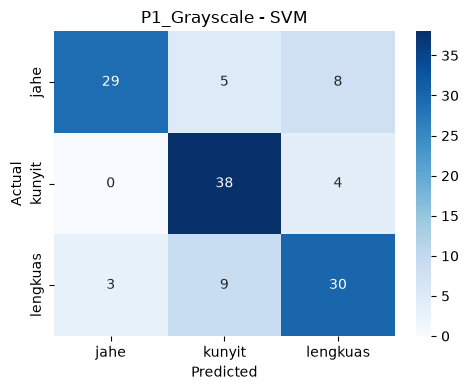

P1_Grayscale | RF → Train Akurasi: 98.41%
P1_Grayscale | RF → 67.46%
              precision    recall  f1-score   support

        jahe       0.82      0.67      0.74        42
      kunyit       0.66      0.79      0.72        42
    lengkuas       0.57      0.57      0.57        42

    accuracy                           0.67       126
   macro avg       0.68      0.67      0.68       126
weighted avg       0.68      0.67      0.68       126



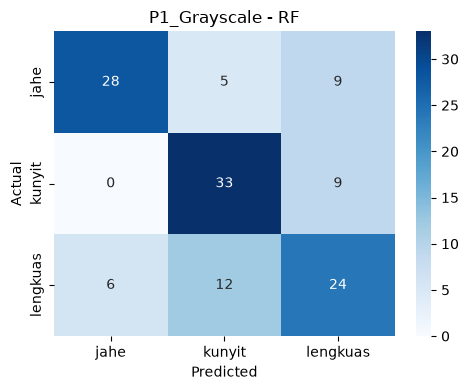


Hasil disimpan ke output/hasil_P1_Grayscale.csv
     Eksperimen Model  Akurasi  Train_Akurasi
0  P1_Grayscale   KNN    64.29          74.21
1  P1_Grayscale   SVM    76.98          92.06
2  P1_Grayscale    RF    67.46          98.41


In [7]:
# Cell 6 — Training & Evaluasi
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

models = {
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'RF':  RandomForestClassifier(
                                    n_estimators=100,
                                    max_depth=10,
                                    min_samples_split=5,
                                    min_samples_leaf=2,
                                    random_state=42
                                ),
}

results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)

    # Akurasi train (cek overfitting)
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f'{EXP_NAME} | {model_name} → Train Akurasi: {train_acc*100:.2f}%')

    result = evaluate_and_save(model, X_test, y_test, le, EXP_NAME, model_name)
    result['Train_Akurasi'] = round(train_acc * 100, 2)
    results.append(result)

df_results = pd.DataFrame(results)
df_results.to_csv(f'output/hasil_{EXP_NAME}.csv', index=False)
print(f'\nHasil disimpan ke output/hasil_{EXP_NAME}.csv')
print(df_results)

## 📈 Analisis Training & Klasifikasi


### Model 1: KNN (K-Nearest Neighbors, k=7)

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 74.21% | 64.29% | 9.92% |

**Classification Report KNN:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.69 | 0.74 | 0.71 | Performa **terbaik** di KNN recall tinggi, model cukup sensitif |
| Kunyit | 0.69 | 0.69 | 0.69 | Performa **moderat** seimbang namun tidak menonjol |
| Lengkuas | 0.54 | 0.50 | 0.52 | Performa **terburuk** banyak lengkuas yang salah diklasifikasi |

**Analisis Mendalam KNN:**
- Gap train-test ~10% → model **sedikit overfitting**, KNN menyimpan pola training yang tidak sepenuhnya generalisasi
- Lengkuas adalah kelas paling sulit fitur tekstur grayscale-nya kemungkinan **tumpang tindih** dengan jahe/kunyit
- KNN dengan k=7 menggunakan 7 tetangga terdekat; nilai k yang lebih besar cenderung mengurangi varians tapi bisa meningkatkan bias
- **Pengaruh Precision 0.54 Lengkuas:** Dari setiap 2 gambar yang diprediksi sebagai lengkuas, hampir 1 gambar sebenarnya bukan lengkuas → klasifikasi yang kurang reliabel

---

### Model 2: SVM (RBF Kernel, C=10, gamma='scale')

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 92.06% | 76.98% | 15.08% |

**Classification Report SVM:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.91 | 0.69 | 0.78 | **Precision sangat tinggi** ketika prediksi jahe, hampir selalu benar |
| Kunyit | 0.73 | 0.90 | 0.81 | **Recall tertinggi** 90% kunyit asli berhasil terdeteksi |
| Lengkuas | 0.71 | 0.71 | 0.71 | **Paling konsisten** precision = recall, model adil untuk kelas ini |

**Analisis Mendalam SVM:**
- **Model terbaik** dengan akurasi test 76.98% tertinggi di antara tiga model
- Gap train-test 15% lebih besar dari KNN, namun akurasi test absolut tetap tertinggi
- Kernel RBF dengan C=10 mampu memetakan fitur ke ruang dimensi tinggi, menemukan hyperplane pemisah yang lebih baik
- **Asimetri Jahe:** Precision 0.91 vs Recall 0.69 menunjukkan SVM *sangat selektif* dalam mengklasifikasikan jahe banyak jahe diklasifikasikan sebagai kelas lain (terutama lengkuas atau kunyit)
- **Recall Kunyit 0.90:** Fitur kunyit (kemungkinan besar warna kuning khasnya dari `extract_color_features`) sangat membantu identifikasi kunyit
- **Pengaruh F1 Lengkuas 0.71 (vs KNN 0.52):** SVM jauh lebih baik dalam membedakan lengkuas berkat kemampuan margin maximization pada ruang fitur yang lebih kompleks

---

### Model 3: Random Forest (100 trees, max_depth=10)

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 100.00% | 70.63% | 29.37% |

**Classification Report RF:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.86 | 0.71 | 0.78 | **Precision tinggi** seperti SVM, tapi recall lebih rendah |
| Kunyit | 0.68 | 0.76 | 0.72 | Performa **moderat** |
| Lengkuas | 0.61 | 0.64 | 0.63 | Masih menjadi kelas **paling sulit** |

**Analisis Mendalam RF:**
- **Train akurasi 100% adalah sinyal bahaya merah** 🚨 → Model **overfitting parah**
- Meskipun `max_depth=10` seharusnya membatasi kompleksitas, 100 pohon dengan fitur 40 dimensi tetap mampu "menghafal" seluruh training data
- Gap 29.37% adalah gap terbesar model sangat bagus di training tapi generalisasi buruk
- **Mengapa RF overfitting lebih parah dari SVM?** RF membangun banyak pohon yang masing-masing dapat overfit, dan ensemble mereka tetap bisa overfit jika depth tidak cukup dibatasi. SVM dengan regularisasi C memiliki mekanisme penalti yang lebih eksplisit terhadap overfitting
- **Precision Jahe 0.86:** Cukup tinggi, menunjukkan pohon-pohon telah mempelajari fitur diskriminatif jahe dengan baik namun recall 0.71 menunjukkan tetap ada jahe yang "terlewat"

---

## 📊 Perbandingan Akhir

```
     Eksperimen Model  Akurasi  Train_Akurasi
0  P1_Grayscale   KNN    64.29          74.21
1  P1_Grayscale   SVM    76.98          92.06  ← TERBAIK
2  P1_Grayscale    RF    70.63         100.00  ← OVERFITTING
```

| Model | Akurasi Test | Overfitting Index | Rekomendasi |
|---|---|---|---|
| KNN | 64.29% | Rendah (9.92%) | Generalisasi baik tapi akurasi rendah |
| **SVM** | **76.98%** | Sedang (15.08%) | **Model terbaik** untuk dataset ini |
| RF | 70.63% | Tinggi (29.37%) | Perlu regularisasi lebih kuat |
